In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Veriyi yükle
df = pd.read_excel("/Users/aleynagulkazdal/Desktop/Bitirme/WiAR-master/distance_factor_activity_data/1m_data/sample_antenna_A.xls", header=None)

# Normalizasyon
df_normalized = (df - df.min()) / (df.max() - df.min())

# Model formatına getir
X = df_normalized.values.reshape(-1, 200, 1)

# Etiketler
labels = np.repeat(np.arange(16), 300)

# Train/test böl
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)


In [3]:
print("Eksik değerler:", df.isnull().sum().sum())
print("Min değer:", df.min().min())
print("Max değer:", df.max().max())
print("Ortalama:", df.mean().mean())

Eksik değerler: 0
Min değer: -4.771212547196626
Max değer: 30.726174765452356
Ortalama: 16.854836474948947


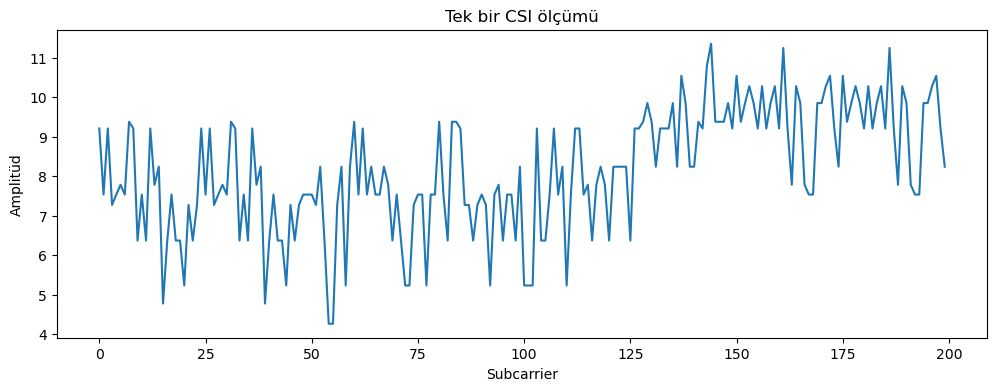

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[0].values)
plt.title("Tek bir CSI ölçümü")
plt.xlabel("Subcarrier")
plt.ylabel("Amplitüd")
plt.show()

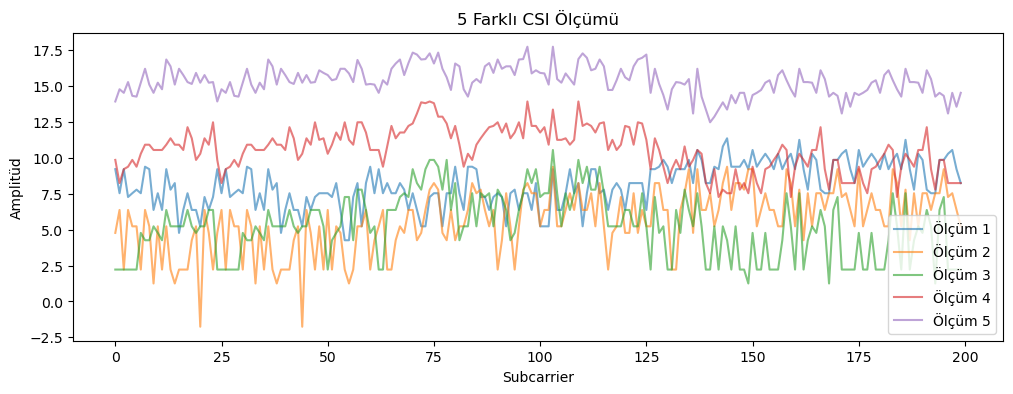

In [5]:
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.plot(df.iloc[i].values, alpha=0.6, label=f"Ölçüm {i+1}")
plt.title("5 Farklı CSI Ölçümü")
plt.xlabel("Subcarrier")
plt.ylabel("Amplitüd")
plt.legend()
plt.show()

In [6]:
# Normalizasyon
df_normalized = (df - df.min()) / (df.max() - df.min())

print("Min değer (sonra):", df_normalized.min().min())
print("Max değer (sonra):", df_normalized.max().max())

Min değer (sonra): 0.0
Max değer (sonra): 1.0


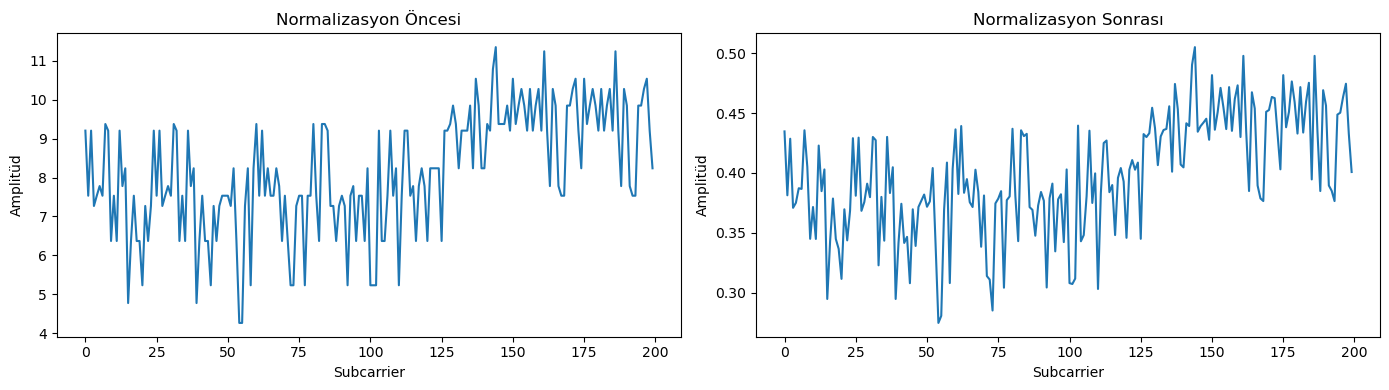

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(df.iloc[0].values)
ax1.set_title("Normalizasyon Öncesi")
ax1.set_xlabel("Subcarrier")
ax1.set_ylabel("Amplitüd")

ax2.plot(df_normalized.iloc[0].values)
ax2.set_title("Normalizasyon Sonrası")
ax2.set_xlabel("Subcarrier")
ax2.set_ylabel("Amplitüd")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np

X = df_normalized.values  # Girdi verisi
print("Veri şekli:", X.shape)

# Modelin beklediği format: (örnekler, zaman adımları, özellikler)
X = X.reshape(X.shape[0], X.shape[1], 1)
print("Yeni şekil:", X.shape)

Veri şekli: (4800, 200)
Yeni şekil: (4800, 200, 1)


In [9]:
# Kaç tane hareket var ve kaç örnek?
print("Toplam örnek sayısı:", X.shape[0])

# Her hareketten 30 örnek var, 16 hareket var
# 30 x 16 = 480 örnek per volunteer
# Toplam 4800 / 30 = 160... kontrol edelim
print("30'a bölünce:", X.shape[0] / 30)
print("16'ya bölünce:", X.shape[0] / 16)

Toplam örnek sayısı: 4800
30'a bölünce: 160.0
16'ya bölünce: 300.0


In [10]:
# Her hareketten 300 örnek var, 16 hareket var
# Etiketler: 0,0,0... 1,1,1... 2,2,2... şeklinde
labels = np.repeat(np.arange(16), 300)

print("Etiket şekli:", labels.shape)
print("Benzersiz etiketler:", np.unique(labels))
print("İlk 10 etiket:", labels[:10])
print("Son 10 etiket:", labels[-10:])

Etiket şekli: (4800,)
Benzersiz etiketler: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
İlk 10 etiket: [0 0 0 0 0 0 0 0 0 0]
Son 10 etiket: [15 15 15 15 15 15 15 15 15 15]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    
    X, labels, test_size=0.2, random_state=42
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)
print("Eğitim etiketleri:", y_train.shape)
print("Test etiketleri:", y_test.shape)

Eğitim seti: (3840, 200, 1)
Test seti: (960, 200, 1)
Eğitim etiketleri: (3840,)
Test etiketleri: (960,)
